# Análise da Camada Silver

Este notebook analisa a BigTable da camada Silver do projeto Mapa da Cidadania e Acesso à Informação no DF.

A tabela principal é `tb_mapa_cidadania_ra_ano_silver.csv`.

A granularidade da tabela é:

```text
1 linha = 1 Região Administrativa + 1 ano.
```

A base foi construída a partir da integração entre a PDAD-A 2024 e as Projeções Populacionais por Região Administrativa 2020-2030.

A base Participa DF/LAI não foi integrada à BigTable territorial por não possuir coluna territorial confiável de Região Administrativa.

## 1. Carregamento da BigTable

In [1]:
import warnings
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("viridis")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "silver":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "Data Layer":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif PROJECT_ROOT.name == "Transformer":
    PROJECT_ROOT = PROJECT_ROOT.parent

SILVER_DIR = PROJECT_ROOT / "Data Layer" / "silver"

df = pd.read_csv(SILVER_DIR / "tb_mapa_cidadania_ra_ano_silver.csv")
df.head()

,ano,regiao_administrativa,ano_referencia_pdad,populacao_total,populacao_masculina,populacao_feminina,populacao_0_14,populacao_15_59,populacao_60_mais,renda_media_ponderada,idade_media_ponderada,media_moradores_por_domicilio,percentual_baixa_escolaridade,percentual_domicilios_com_internet,percentual_domicilios_proprios,percentual_domicilios_alugados,lai_df_qtd_pedidos_ano,lai_df_qtd_recursos_ano,lai_df_qtd_satisfacoes_ano,lai_df_percentual_pedidos_com_recurso,lai_df_tempo_medio_resposta_dias,lai_df_percentual_acesso_concedido,lai_df_percentual_acesso_negado,lai_df_percentual_acesso_parcial,lai_df_percentual_sem_resposta,lai_df_qtd_orgaos_demandados
0,2023,Arniqueira,2024,47516.00,23191.00,24325.00,8875.00,33832.00,4809.00,733.10,34.73,2.72,31.11,96.19,63.25,30.46,20608,1317,2601,6.30,8.58,54.88,6.89,3.84,43.49,96
1,2024,Arniqueira,2024,47767.00,23319.00,24448.00,8695.00,34010.00,5062.00,733.10,34.73,2.72,31.11,96.19,63.25,30.46,23082,1388,2658,5.86,7.57,52.90,9.25,4.18,17.69,96
2,2025,Arniqueira,2024,47932.00,23407.00,24525.00,8525.00,34090.00,5317.00,733.10,34.73,2.72,31.11,96.19,63.25,30.46,27256,1293,2110,4.58,8.05,53.47,8.71,3.70,16.67,96
3,2023,Brazlândia,2024,65773.00,32287.00,33486.00,13959.00,44159.00,7655.00,765.10,33.46,2.85,36.09,89.47,58.15,28.32,20608,1317,2601,6.30,8.58,54.88,6.89,3.84,43.49,96
4,2024,Brazlândia,2024,66304.00,32521.00,33783.00,13871.00,44418.00,8015.00,765.10,33.46,2.85,36.09,89.47,58.15,28.32,23082,1388,2658,5.86,7.57,52.90,9.25,4.18,17.69,96


## 2. Diagnóstico estrutural

Verificações de linhas, colunas, tipos de dados, período disponível, quantidade de Regiões Administrativas, nulos e duplicidades.

In [2]:
diagnostico = pd.DataFrame({
    "metrica": [
        "linhas",
        "colunas",
        "ano_minimo",
        "ano_maximo",
        "qtd_anos",
        "qtd_regioes_administrativas",
        "total_nulos",
        "duplicidades_ra_ano",
    ],
    "valor": [
        len(df),
        len(df.columns),
        int(df["ano"].min()),
        int(df["ano"].max()),
        df["ano"].nunique(),
        df["regiao_administrativa"].nunique(),
        int(df.isna().sum().sum()),
        int(df.duplicated(["regiao_administrativa", "ano"]).sum()),
    ],
})

display(diagnostico)
display(df.dtypes.rename("tipo").reset_index().rename(columns={"index": "coluna"}))
display(df.isna().sum().rename("qtd_nulos").reset_index().rename(columns={"index": "coluna"}))

,metrica,valor
0,linhas,99
1,colunas,26
2,ano_minimo,2023
3,ano_maximo,2025
4,qtd_anos,3
5,qtd_regioes_administrativas,33
6,total_nulos,0
7,duplicidades_ra_ano,0


,coluna,tipo
0,ano,int64
1,regiao_administrativa,str
2,ano_referencia_pdad,int64
3,populacao_total,float64
4,populacao_masculina,float64
5,populacao_feminina,float64
6,populacao_0_14,float64
7,populacao_15_59,float64
8,populacao_60_mais,float64
9,renda_media_ponderada,float64


,coluna,qtd_nulos
0,ano,0
1,regiao_administrativa,0
2,ano_referencia_pdad,0
3,populacao_total,0
4,populacao_masculina,0
5,populacao_feminina,0
6,populacao_0_14,0
7,populacao_15_59,0
8,populacao_60_mais,0
9,renda_media_ponderada,0


## 3. Validação da chave

A chave lógica da BigTable é `regiao_administrativa + ano`. O resultado esperado é 0 duplicidades.

In [3]:
duplicidades = (
    df.groupby(["regiao_administrativa", "ano"])
    .size()
    .reset_index(name="qtd")
    .query("qtd > 1")
)

duplicidades

,regiao_administrativa,ano,qtd


## 4. Diagnóstico dos nulos socioeconômicos

Validação dos indicadores principais derivados da PDAD-A 2024. O resultado esperado é 0 linhas com nulos socioeconômicos.

In [4]:
cols_pdad = [
    "renda_media_ponderada",
    "idade_media_ponderada",
    "media_moradores_por_domicilio",
    "percentual_baixa_escolaridade",
    "percentual_domicilios_com_internet",
    "percentual_domicilios_proprios",
    "percentual_domicilios_alugados",
]

df[df[cols_pdad].isna().any(axis=1)][
    ["ano", "regiao_administrativa"] + cols_pdad
]

,ano,regiao_administrativa,renda_media_ponderada,idade_media_ponderada,media_moradores_por_domicilio,percentual_baixa_escolaridade,percentual_domicilios_com_internet,percentual_domicilios_proprios,percentual_domicilios_alugados


## 5. Análise populacional

Análise de população total por RA, população por ano, RAs mais populosas e variação populacional entre 2023 e 2025.

,ano,populacao_total
0,2023,3167502.00
1,2024,3204070.00
2,2025,3239675.00


,regiao_administrativa,populacao_total
3,Ceilândia,356176.33
22,Samambaia,260866.67
16,Plano Piloto,245759.33
29,Taguatinga,215884.33
15,Planaltina,214633.33
6,Gama,146249.00
17,Recanto das Emas,145441.00
7,Guará,145082.67
23,Santa Maria,132503.67
32,Águas Claras,129285.00


ano,regiao_administrativa,2023,2024,2025,variacao_2023_2025,variacao_percentual_2023_2025
8,Itapoã,83461.00,90667.00,97667.00,14206.00,17.02
15,Planaltina,210578.00,214753.00,218569.00,7991.00,3.79
22,Samambaia,257172.00,261025.00,264403.00,7231.00,2.81
17,Recanto das Emas,142331.00,145518.00,148474.00,6143.00,4.32
16,Plano Piloto,242808.00,245902.00,248568.00,5760.00,2.37
25,Sobradinho II,79594.00,80006.00,84744.00,5150.00,6.47
29,Taguatinga,214109.00,215979.00,217565.00,3456.00,1.61
26,Sol Nascente/Pôr do Sol,96703.00,98447.00,99984.00,3281.00,3.39
32,Águas Claras,128144.00,129369.00,130342.00,2198.00,1.72
9,Jardim Botânico,61261.00,62271.00,63186.00,1925.00,3.14


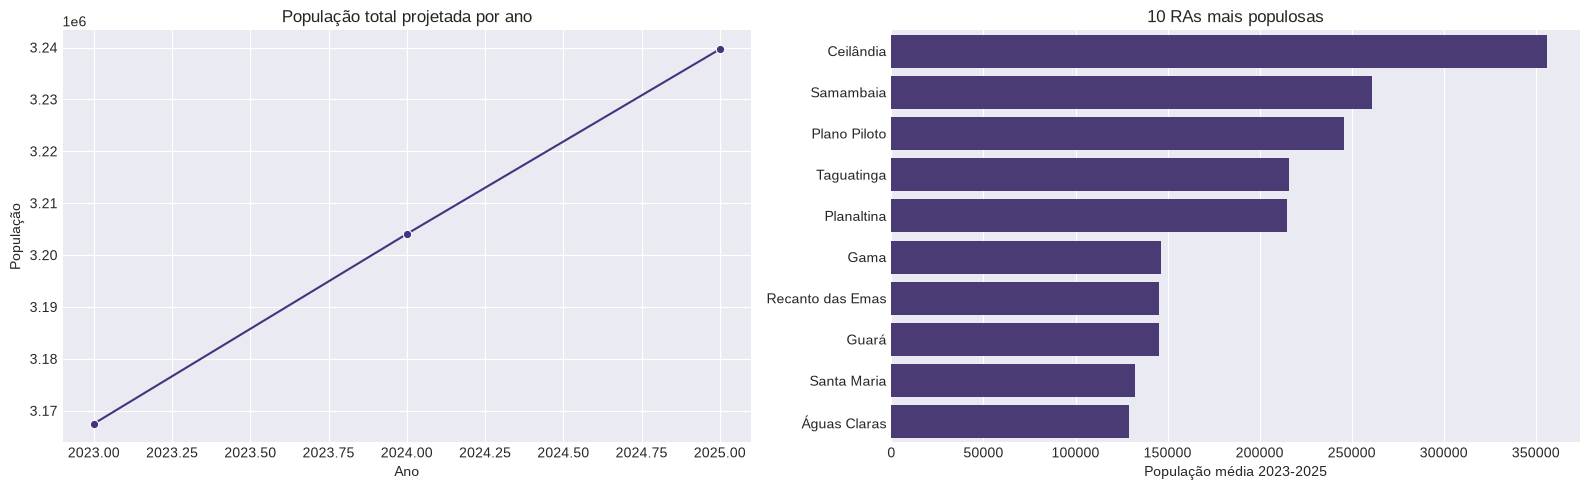

In [5]:
pop_ano = df.groupby("ano", as_index=False)["populacao_total"].sum()
pop_ra = df.groupby("regiao_administrativa", as_index=False)["populacao_total"].mean().sort_values("populacao_total", ascending=False)

pop_variacao = (
    df.pivot(index="regiao_administrativa", columns="ano", values="populacao_total")
    .reset_index()
)
pop_variacao["variacao_2023_2025"] = pop_variacao[2025] - pop_variacao[2023]
pop_variacao["variacao_percentual_2023_2025"] = 100 * pop_variacao["variacao_2023_2025"] / pop_variacao[2023]
pop_variacao = pop_variacao.sort_values("variacao_2023_2025", ascending=False)

display(pop_ano)
display(pop_ra.head(10))
display(pop_variacao.head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=pop_ano, x="ano", y="populacao_total", marker="o", ax=axes[0])
axes[0].set_title("População total projetada por ano")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("População")

sns.barplot(data=pop_ra.head(10), y="regiao_administrativa", x="populacao_total", ax=axes[1])
axes[1].set_title("10 RAs mais populosas")
axes[1].set_xlabel("População média 2023-2025")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 6. Análise socioeconômica

Análise de renda média ponderada, idade média ponderada, baixa escolaridade, internet domiciliar, domicílios próprios e domicílios alugados.

,regiao_administrativa,renda_media_ponderada,idade_media_ponderada,media_moradores_por_domicilio,percentual_baixa_escolaridade,percentual_domicilios_com_internet,percentual_domicilios_proprios,percentual_domicilios_alugados
20,SCIA,247.74,27.59,3.02,44.26,81.89,75.29,18.41
21,SIA,269.20,30.82,2.99,31.66,94.00,43.33,34.00
5,Fercal,273.24,30.70,2.94,40.18,83.25,67.50,24.00
13,Paranoá,283.52,31.73,2.87,36.86,92.67,62.50,30.82
26,Sol Nascente/Pôr do Sol,308.17,29.47,2.97,40.26,88.22,68.92,23.56
30,Varjão,373.75,29.03,2.84,39.07,87.78,50.61,41.08
8,Itapoã,384.37,29.55,2.78,36.36,95.76,68.58,26.93
19,Riacho Fundo II,435.90,32.17,3.03,31.63,96.26,67.58,28.43
17,Recanto das Emas,439.23,32.02,2.99,37.38,88.05,62.61,29.42
23,Santa Maria,445.13,33.09,3.24,33.74,94.24,71.18,23.06


,renda_media_ponderada,idade_media_ponderada,media_moradores_por_domicilio,percentual_baixa_escolaridade,percentual_domicilios_com_internet,percentual_domicilios_proprios,percentual_domicilios_alugados
count,33.00,33.00,33.00,33.00,33.00,33.00,33.00
mean,1153.83,34.76,2.80,29.05,93.85,63.73,29.30
std,1142.54,3.90,0.28,8.54,4.57,10.46,9.41
min,247.74,27.59,1.97,12.73,81.89,43.33,6.27
25%,439.23,32.02,2.64,20.91,91.53,58.15,25.52
50%,765.10,34.73,2.87,29.39,94.11,62.72,28.85
75%,1283.05,37.10,2.99,36.09,96.99,68.60,34.58
max,5255.80,44.63,3.24,44.26,100.00,86.72,51.77


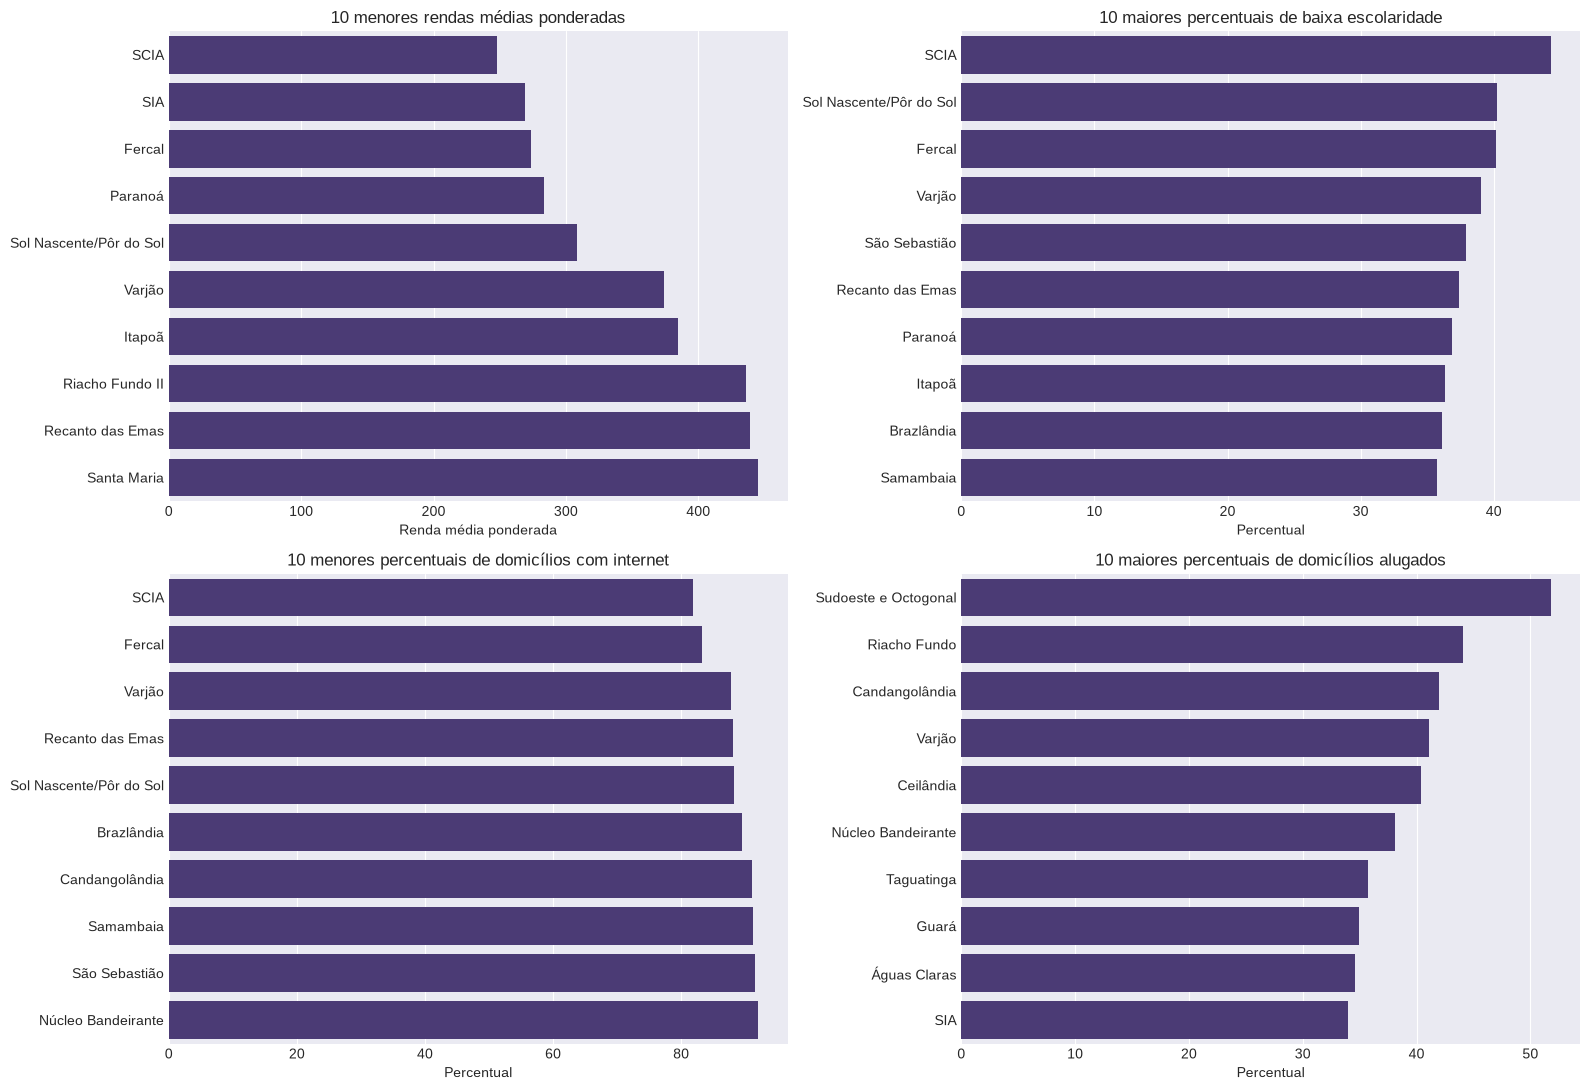

In [6]:
socio = (
    df.groupby("regiao_administrativa", as_index=False)[cols_pdad]
    .mean()
    .sort_values("renda_media_ponderada")
)

display(socio.head(10))
display(socio.describe())

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.barplot(data=socio.head(10), y="regiao_administrativa", x="renda_media_ponderada", ax=axes[0, 0])
axes[0, 0].set_title("10 menores rendas médias ponderadas")
axes[0, 0].set_xlabel("Renda média ponderada")
axes[0, 0].set_ylabel("")

baixa = socio.sort_values("percentual_baixa_escolaridade", ascending=False).head(10)
sns.barplot(data=baixa, y="regiao_administrativa", x="percentual_baixa_escolaridade", ax=axes[0, 1])
axes[0, 1].set_title("10 maiores percentuais de baixa escolaridade")
axes[0, 1].set_xlabel("Percentual")
axes[0, 1].set_ylabel("")

internet = socio.sort_values("percentual_domicilios_com_internet").head(10)
sns.barplot(data=internet, y="regiao_administrativa", x="percentual_domicilios_com_internet", ax=axes[1, 0])
axes[1, 0].set_title("10 menores percentuais de domicílios com internet")
axes[1, 0].set_xlabel("Percentual")
axes[1, 0].set_ylabel("")

alugados = socio.sort_values("percentual_domicilios_alugados", ascending=False).head(10)
sns.barplot(data=alugados, y="regiao_administrativa", x="percentual_domicilios_alugados", ax=axes[1, 1])
axes[1, 1].set_title("10 maiores percentuais de domicílios alugados")
axes[1, 1].set_xlabel("Percentual")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()

## 7. Conclusão da Camada Silver

A camada Silver consolidou dados públicos heterogêneos da PDAD-A 2024, do Participa DF/LAI e das Projeções Populacionais por Região Administrativa em uma BigTable analítica com granularidade:

**1 linha = 1 Região Administrativa + 1 ano.**

A tabela apresenta cobertura de:

- 33 Regiões Administrativas;
- anos de 2023, 2024 e 2025;
- 99 combinações únicas de RA + ano;
- 26 colunas no contrato final;
- `ano_referencia_pdad = 2024`;
- 0 duplicidades na chave lógica;
- 0 valores vazios no artefato atualmente gerado.

Os dados populacionais representam praticamente todo o Distrito Federal e indicam crescimento consolidado de 3.167.502 habitantes em 2023 para 3.239.675 em 2025, uma variação de aproximadamente 72.173 pessoas ou 2,28%.

As maiores altas absolutas de população entre 2023 e 2025 foram observadas em Itapoã, Planaltina, Samambaia, Recanto das Emas e Plano Piloto.

Os indicadores socioeconômicos utilizam a PDAD-A 2024 como fotografia territorial de referência. Nessa referência, observam-se diferenças expressivas entre as Regiões Administrativas em renda, escolaridade, condições domiciliares e acesso à internet.

As menores rendas médias ponderadas aparecem em SCIA, SIA, Fercal, Paranoá e Sol Nascente/Pôr do Sol, enquanto as maiores aparecem em Lago Sul, Plano Piloto, Park Way, Sudoeste/Octogonal e Lago Norte.

Os indicadores da LAI foram agregados no nível Distrito Federal + ano, pois a fonte não possui dimensão territorial confiável por Região Administrativa. Por isso, seus valores são repetidos entre as RAs do mesmo ano apenas como contexto anual e não devem ser somados ou interpretados como medidas territoriais específicas.

No período de 2023 a 2025, foram observados:

- 70.946 pedidos de acesso à informação;
- 3.998 recursos;
- 7.369 avaliações de satisfação.

O número de pedidos aumentou de 20.608 em 2023 para 27.256 em 2025.

O contrato da Silver foi alinhado entre CSV, DDL e consultas SQL, incluindo `ano_referencia_pdad` e a métrica `lai_df_percentual_pedidos_com_recurso`, calculada a partir de pedidos únicos com pelo menos um recurso.

Com esse alinhamento, a camada Silver está pronta para ter seu contrato protegido por testes automatizados e seguir para PostgreSQL e camada Gold.
